# Geometric Brownian Motion and the Bot's Barrier Pricer

**A guided derivation, simulation, and reality-check of the math behind `backend/core/monte_carlo.prob_one_touch_above_analytic`.**

This notebook is for understanding, not for production. Nothing here is imported by the bot. The goal: by the end, you can point at any line of the production pricer and say what mathematical role it plays — and you can explain *why* it's an approximation rather than a truth.

## What you'll learn

1. What Geometric Brownian Motion (GBM) is and what its SDE means in plain English.
2. The four assumptions GBM makes about asset prices, and how poorly real BTC matches each.
3. How to derive the closed-form one-touch barrier probability from the reflection principle.
4. How to verify that closed-form numerically with a Monte Carlo simulator built from scratch.
5. Three concrete failure modes (vol misestimation, fat tails, jumps) and how each shows up in barrier-touch probability.
6. A line-by-line read of the production code so it stops being a black box.

## Prerequisites

You should be comfortable with calculus and have seen the words "stochastic process" before. You don't need a finance background — this notebook explains finance terms as they come up.

In [1]:
# Notebook libraries (no production code yet — that comes in Section 3).
import sys
from pathlib import Path

# The notebook lives in /notebooks but imports from /backend later. Put the
# repo root on sys.path so `from backend...` resolves.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reproducible randomness across re-runs.
RNG = np.random.default_rng(seed=20260425)

# Display settings
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Libraries imported. RNG seeded for reproducibility.")

Libraries imported. RNG seeded for reproducibility.


---

## Section 1: What is Geometric Brownian Motion?

### The intuition

Prices don't move in fixed dollar amounts. A $100 move when BTC is at $1,000 is a 10% earthquake. A $100 move when BTC is at $77,000 is a yawn. So when we model price dynamics, we want the *size* of random fluctuations to scale with the price level — a 1% move should look "the same" whether BTC is at $1k or $77k.

That's the central idea of Geometric Brownian Motion: prices move continuously, with random fluctuations whose *magnitude is proportional to the current price level*. The "geometric" in the name means multiplicative (percent moves) rather than additive (dollar moves).

### The SDE

Formally, GBM is the stochastic differential equation

$$
dS_t = \mu \, S_t \, dt + \sigma \, S_t \, dW_t
$$

Read it term-by-term:

- $S_t$ is the price at time $t$.
- $dS_t$ is the infinitesimal change in price over an infinitesimal time interval $dt$.
- $\mu$ (mu) is the **drift**: the average percent return per unit time. If $\mu = 0.10$ per year, the price tends to grow at 10%/year on average.
- $\sigma$ (sigma) is the **volatility**: the typical magnitude of percent fluctuations per unit time. If $\sigma = 0.60$ per year, returns scatter with annualized standard deviation 60%.
- $dW_t$ is an increment of a **Wiener process** (a.k.a. standard Brownian motion). You can think of $dW_t$ as $\sqrt{dt} \cdot Z$ where $Z \sim \mathcal{N}(0, 1)$ — a Gaussian noise term that scales as the square root of time.

Both terms — drift and diffusion — are *multiplied* by $S_t$. That's the geometric scaling.

### Working in log-space

The thing that makes GBM pleasant to work with is that **the log of the price is just a regular Brownian motion with drift**. Specifically:

$$
d(\ln S_t) = \left(\mu - \tfrac{1}{2}\sigma^2\right) dt + \sigma \, dW_t
$$

Two things to notice:

1. The right-hand side is no longer multiplied by $S_t$. In log-space, the dynamics are *additive*. So $\ln S_t$ is exactly a Brownian motion with drift $(\mu - \tfrac{1}{2}\sigma^2)$ and diffusion $\sigma$.
2. There's a mysterious $-\tfrac{1}{2}\sigma^2$ correction. This comes from **Itô's lemma**, which is the stochastic-calculus analog of the chain rule. The intuition (without proof): when you transform a stochastic process by a nonlinear function like $\ln$, you pick up a second-order correction that doesn't appear in ordinary calculus, because Brownian motion has nonzero quadratic variation. Roughly: $(dW_t)^2$ behaves like $dt$, not zero. The Taylor expansion of $\ln$ has a $-\tfrac{1}{2}$ coefficient on the second-derivative term, which combines with $\sigma^2 dt$ from $(dW_t)^2$ to give the famous $-\tfrac{1}{2}\sigma^2$ correction.

If that paragraph went over your head, here's the takeaway: **the drift of the log-price is $(\mu - \tfrac{1}{2}\sigma^2)$, not $\mu$**. The expected value of $S_t$ is $S_0 e^{\mu t}$, but the median of $\ln S_t$ moves with the smaller drift $\mu - \tfrac{1}{2}\sigma^2$. This will matter when we derive the barrier formula in Section 3.

### The closed-form solution

Integrating the log-price SDE from time $0$ to time $T$ gives:

$$
S_T = S_0 \cdot \exp\!\left( \left(\mu - \tfrac{1}{2}\sigma^2\right) T + \sigma \sqrt{T} \, Z \right), \quad Z \sim \mathcal{N}(0, 1)
$$

This is the equation the bot uses (look at `backend/core/monte_carlo.simulate_terminal_prices`). To draw one terminal price, draw one standard normal $Z$, plug in. To draw 10,000 paths, draw 10,000 normals.

### Visualization: 100 simulated BTC paths over 1 year

Let's plot what GBM looks like with reasonable BTC parameters: $S_0 = \$77{,}000$, $\mu = 10\%$/year, $\sigma = 60\%$/year, $T = 1$ year, daily timesteps.

In [2]:
# Notebook helper: simulate n_paths GBM price paths with n_steps timesteps.
# Returns array of shape (n_paths, n_steps + 1) where column 0 = spot.
def simulate_gbm_paths(spot, mu, sigma, T, n_steps, n_paths, rng):
    dt = T / n_steps
    drift = (mu - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt)
    increments = drift + diffusion * rng.standard_normal((n_paths, n_steps))
    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.concatenate([np.zeros((n_paths, 1)), log_paths], axis=1)
    return spot * np.exp(log_paths)


# BTC-like parameters
S0_BTC = 77_000.0
MU_BTC = 0.10
SIGMA_BTC = 0.60
T_ONE_YEAR = 1.0
N_DAILY_STEPS = 252  # ~trading days

paths_1y = simulate_gbm_paths(
    spot=S0_BTC, mu=MU_BTC, sigma=SIGMA_BTC,
    T=T_ONE_YEAR, n_steps=N_DAILY_STEPS, n_paths=100, rng=RNG,
)
paths_1y.shape

(100, 253)

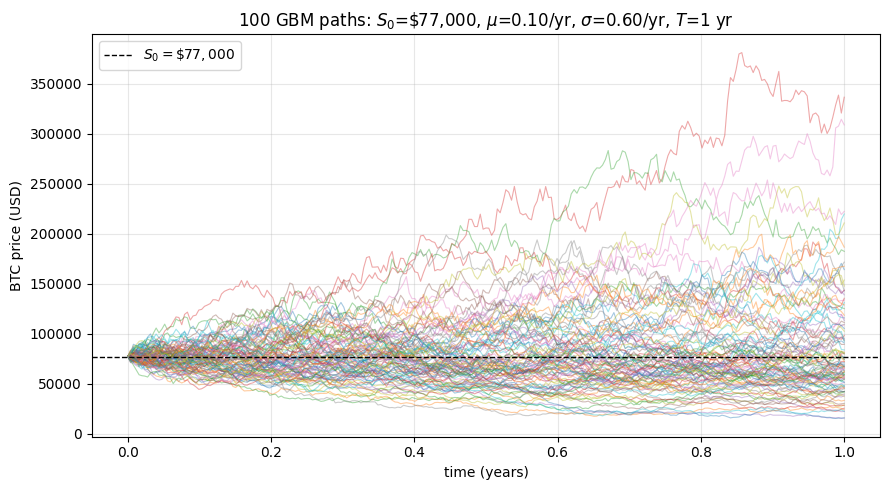

Terminal-price stats over 100 paths:
  mean   = $      87,714
  median = $      68,501
  min    = $      15,573
  max    = $     336,506


In [3]:
# Plot the 100 paths
time_grid = np.linspace(0, T_ONE_YEAR, N_DAILY_STEPS + 1)
fig, ax = plt.subplots()
ax.plot(time_grid, paths_1y.T, alpha=0.4, linewidth=0.8)
ax.axhline(S0_BTC, color="black", linestyle="--", linewidth=1, label=f"$S_0 = \${S0_BTC:,.0f}$")
ax.set_xlabel("time (years)")
ax.set_ylabel("BTC price (USD)")
ax.set_title(f"100 GBM paths: $S_0$=\${S0_BTC:,.0f}, $\mu$={MU_BTC:.2f}/yr, $\sigma$={SIGMA_BTC:.2f}/yr, $T$=1 yr")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Terminal-price stats over {paths_1y.shape[0]} paths:")
print(f"  mean   = ${paths_1y[:, -1].mean():>12,.0f}")
print(f"  median = ${np.median(paths_1y[:, -1]):>12,.0f}")
print(f"  min    = ${paths_1y[:, -1].min():>12,.0f}")
print(f"  max    = ${paths_1y[:, -1].max():>12,.0f}")

Notice three things in the plot:

1. **All paths fan out from $S_0$.** Early in time the spread is small; by year-end paths range across roughly an order of magnitude. The fan-shape is the visual signature of $\sqrt{t}$ growth in the Brownian-motion increment.
2. **Paths can never go negative.** The exponential in $S_T = S_0 \exp(\cdot)$ guarantees positivity. This is a *good* feature for asset prices but is also one of GBM's strongest commitments: it cannot model anything that has a non-trivial probability of crossing zero.
3. **The mean is higher than the median.** Mean ≫ median because the distribution is log-normal — long right tail. Most paths end up below the mean; a few outsized winners pull the average up. This asymmetry will keep showing up.

---

## Section 2: What assumptions does GBM make about crypto prices?

GBM commits to four things about how prices move. Each is approximately true on short horizons and increasingly wrong on long ones. Since the bot trades daily-cadence Kalshi barriers, we care most about the daily horizon — but it's important to know where the model breaks even there.

### The four assumptions

1. **Constant volatility.** $\sigma$ is the same at every time and at every price level. Real BTC has *volatility clustering*: calm weeks alternate with frantic weeks, and during stress (e.g., March 2020, May 2022, Nov 2022) realized volatility spikes far above its long-run average and stays elevated for days.
2. **Log-normal returns** (i.e., normally distributed log-returns). Real BTC has **fat tails**: extreme moves happen far more often than a normal distribution predicts. A "5-sigma" daily move is supposed to be a 1-in-a-million event under normality; in crypto you get one every couple of years.
3. **Continuous price paths.** No jumps. Real BTC has gaps — Asian-hours liquidity holes, exchange outages, news shocks (regulatory announcements, ETF approvals, hacks). A jump can take the price from $77k to $73k in a single tick, with no opportunity for a barrier monitored at $75k to "see" the path crossing it gradually.
4. **Independent increments.** Knowing today's return tells you nothing about tomorrow's. Real BTC has weak short-horizon momentum and weak long-horizon mean reversion. Both are noisy and hard to time, but they're statistically detectable.

We can demonstrate (1) and (2) on real data right now. Let's pull BTC closes and look.

In [4]:
# Use the bot's existing price-history helper. This is a notebook reading
# production data, not modifying production code.
from backend.data.price_history import fetch_daily_closes

bars = fetch_daily_closes("BTC", "crypto", days=290)
dates = [d for d, _ in bars]
closes = np.array([c for _, c in bars])

print(f"Loaded {len(bars)} daily BTC closes, {dates[0]} -> {dates[-1]}.")
print(f"Range: ${closes.min():,.0f} -> ${closes.max():,.0f}")
print(f"Most recent close: ${closes[-1]:,.2f}")

Loaded 290 daily BTC closes, 2025-07-10 -> 2026-04-25.
Range: $62,791 -> $124,720
Most recent close: $77,599.98


In [5]:
# Daily log-returns. Annualized vol/drift via standard scaling.
log_returns = np.diff(np.log(closes))
mu_realized = log_returns.mean() * 252       # annualized
sigma_realized = log_returns.std() * np.sqrt(252)  # annualized

print(f"Daily log-return stats (n = {len(log_returns)}):")
print(f"  mean  daily = {log_returns.mean():.5f}  -> annualized mu    = {mu_realized:+.3f}")
print(f"  stdev daily = {log_returns.std():.5f}  -> annualized sigma = {sigma_realized:.3f}")
print(f"  min   daily = {log_returns.min():+.4f}")
print(f"  max   daily = {log_returns.max():+.4f}")
print(f"  skewness    = {stats.skew(log_returns):+.3f}  (0 under normal)")
print(f"  excess kurt = {stats.kurtosis(log_returns):+.3f}  (0 under normal; >0 = fat tails)")

Daily log-return stats (n = 289):
  mean  daily = -0.00139  -> annualized mu    = -0.351
  stdev daily = 0.02349  -> annualized sigma = 0.373
  min   daily = -0.1506
  max   daily = +0.1162
  skewness    = -0.537  (0 under normal)
  excess kurt = +7.194  (0 under normal; >0 = fat tails)


The headline number to notice: **excess kurtosis**. Under a normal distribution, excess kurtosis is exactly 0. Real BTC's daily log-returns over the past ~290 days have substantially higher kurtosis. That's the "fat tails" assumption violation, quantified.

Let's visualize it two ways: a histogram of daily returns overlaid with the normal density that GBM would predict, and a QQ-plot.

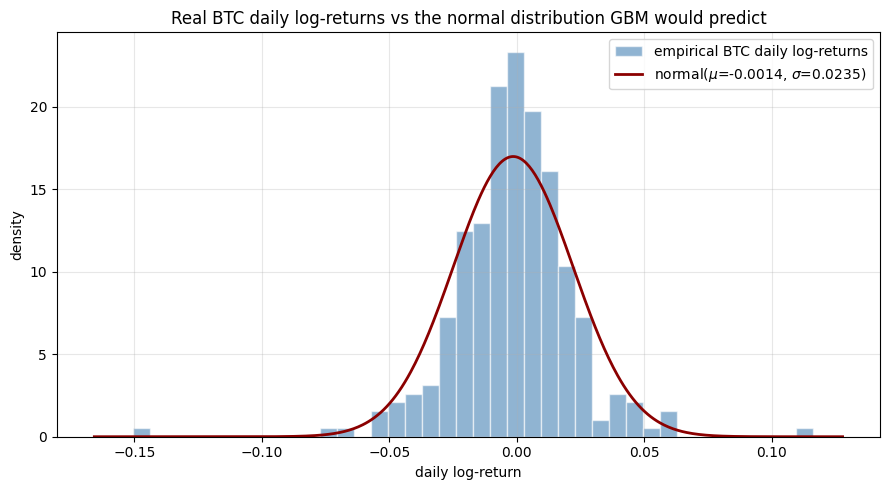

In [6]:
# Histogram of returns overlaid with the GBM-predicted normal density.
fig, ax = plt.subplots()
counts, bin_edges, _ = ax.hist(
    log_returns, bins=40, density=True, alpha=0.6,
    color="steelblue", edgecolor="white", label="empirical BTC daily log-returns",
)
# Fitted normal — same mean and stdev as the empirical sample
x_grid = np.linspace(log_returns.min() * 1.1, log_returns.max() * 1.1, 500)
normal_pdf = stats.norm.pdf(x_grid, loc=log_returns.mean(), scale=log_returns.std())
ax.plot(x_grid, normal_pdf, color="darkred", linewidth=2,
        label=f"normal($\mu$={log_returns.mean():.4f}, $\sigma$={log_returns.std():.4f})")
ax.set_xlabel("daily log-return")
ax.set_ylabel("density")
ax.set_title("Real BTC daily log-returns vs the normal distribution GBM would predict")
ax.legend()
plt.tight_layout()
plt.show()

The bars and the curve mostly agree near the center, but look at the **edges**: the histogram has bars where the red curve is essentially flat against zero. Those are days where BTC moved more than a "5- or 6-sigma" amount — events that, under the normal distribution, should happen about once per ~3 million days. We see several in 290 days.

A QQ-plot makes the tail discrepancy starker:

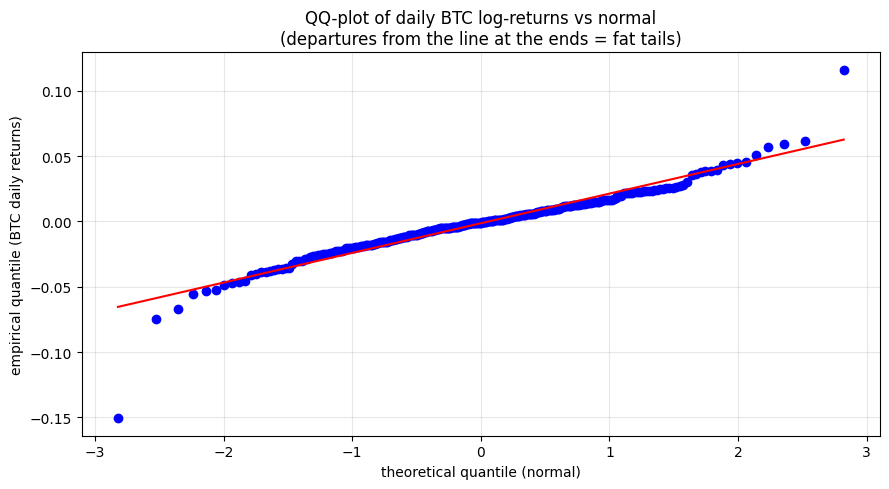

In [7]:
# QQ-plot: empirical quantiles vs theoretical (normal) quantiles.
# A perfect match would lie on a straight line. Departures at the ends =
# the real distribution has heavier tails than the normal.
fig, ax = plt.subplots()
stats.probplot(log_returns, dist="norm", plot=ax)
ax.set_title("QQ-plot of daily BTC log-returns vs normal\n(departures from the line at the ends = fat tails)")
ax.set_xlabel("theoretical quantile (normal)")
ax.set_ylabel("empirical quantile (BTC daily returns)")
plt.tight_layout()
plt.show()

The middle of the QQ-plot follows the diagonal nicely — normality is a fine approximation in the body of the distribution. But the **ends bend away from the line**: empirical points to the lower-left lie below the line (left tail heavier than normal), and points to the upper-right lie above the line (right tail heavier). This is the canonical fat-tail signature.

### Honest summary

GBM is an approximation. For short horizons it captures the bulk of the return distribution well, and the closed-form math is tractable, which is why the bot uses it. But:

- **For barrier products, fat tails matter especially.** A barrier ~3-5% out of the money is in the tail of the daily-return distribution. If real BTC's tails are heavier than GBM predicts, the bot will *underestimate* the probability of a barrier touch, and systematically lose money buying contracts that price these barriers as cheaper-than-fair.
- **The longer the horizon, the worse the approximation.** Volatility clustering and jumps both compound over time. A 7-day daily-cadence Kalshi contract is much closer to GBM's comfort zone than a 30-day monthly contract.

This is the rationale for the GARCH item in `RESEARCH_NOTES.md` Section 11.1: once we have enough settlement data, we'll check whether realized barrier-touch frequencies systematically exceed the bot's GBM predictions. If yes, the cure is a model that handles time-varying volatility.

For now: we're using GBM, we know its limits, and Section 5 will quantify how badly each assumption violation moves the barrier-touch probability.

---

## Section 3: Closed-form barrier-touch probability

### The question

Given:

- Current price $S_0$
- Upper barrier $B > S_0$
- Drift $\mu$ (per year)
- Volatility $\sigma$ (per year)
- Time horizon $T$ (years)

What's the probability that the price hits or exceeds $B$ at *any time* during $[0, T]$?

Formally:

$$
\mathbb{P}\!\left( \max_{0 \le t \le T} S_t \;\ge\; B \right) \;=\; ?
$$

This is the probability the bot needs to price a Kalshi binary one-touch contract: the market pays \$1 if the underlying touches $B$ before expiry, \$0 otherwise.

### Why we can't just use $\mathbb{P}(S_T \ge B)$

A natural first guess: "compute the probability that the *terminal* price $S_T$ is above $B$." That's the lognormal CDF — easy, no path-dependence required. But it's wrong: the path can touch $B$ at some intermediate time and then drift back below by expiry. We'd undercount.

For barrier products we need the distribution of the path's *maximum*, not the distribution of the endpoint.

### The reflection principle (intuitive sketch)

Here's the central trick. Imagine a standard Brownian motion $W_t$ starting at 0, with no drift. We want $\mathbb{P}(\max_{0 \le t \le T} W_t \ge b)$ for some $b > 0$.

The reflection principle says:

$$
\mathbb{P}\!\left( \max_{0 \le t \le T} W_t \ge b \right) \;=\; 2 \cdot \mathbb{P}(W_T \ge b)
$$

Why? Take any path that hits $b$ at some first-touch time $\tau \le T$ and then ends *below* $b$ at time $T$. Reflect that path around the level $b$ from time $\tau$ onward — flip it upside-down across the horizontal line $y = b$. The reflected path ends *above* $b$ at time $T$. Brownian motion is symmetric (no drift), so the reflected path has exactly the same probability density as the original. So for every path that touches $b$ and ends below, there's a corresponding path of equal probability that touches $b$ and ends above. Together those exhaust the touching paths, and the "ends above" half is just $\mathbb{P}(W_T \ge b)$ — endpoint events without path-dependence. So $\mathbb{P}(\text{touch}) = 2 \mathbb{P}(W_T \ge b)$.

(Pictorially: every "down-back" path has a mirror "up-and-stay" twin. Since Brownian motion can't tell up from down at $b$, the two twins are equiprobable.)

### Adding drift and going to GBM

Real prices have drift, so we can't apply the symmetric reflection principle directly. But there's a Girsanov-style adjustment that works: take the log-price $X_t = \ln S_t$, which by Section 1's log-form is a Brownian motion with drift $\tilde\mu = \mu - \tfrac{1}{2}\sigma^2$ and diffusion $\sigma$.

The barrier-touch event $\{ \max_t S_t \ge B \}$ translates to $\{ \max_t X_t \ge \ln B \}$, or equivalently (subtracting $\ln S_0$ from both sides) $\{ \max_t (X_t - \ln S_0) \ge \ln(B/S_0) \}$. Let $b = \ln(B / S_0) > 0$ since $B > S_0$. We need the probability that a *drifted* Brownian motion exceeds $b$ during $[0, T]$.

After applying the drifted-reflection principle (this is Shreve, *Stochastic Calculus for Finance II*, Theorem 7.2.1), the answer is:

$$
\mathbb{P}\!\left( \max_{0 \le t \le T} S_t \ge B \right)
\;=\;
\Phi(d_1) \;+\; \left( \frac{B}{S_0} \right)^{2 \tilde\mu / \sigma^2} \cdot \Phi(d_2)
$$

where

$$
\tilde\mu = \mu - \tfrac{1}{2}\sigma^2,
\qquad
d_1 = \frac{\ln(S_0 / B) + \tilde\mu T}{\sigma \sqrt{T}},
\qquad
d_2 = \frac{\ln(S_0 / B) - \tilde\mu T}{\sigma \sqrt{T}}
$$

and $\Phi$ is the standard normal CDF.

This is exactly what `prob_one_touch_above_analytic` computes (compare to its docstring in `backend/core/monte_carlo.py`).

### Implementation

Let's code the formula and test it on a concrete example: $S_0 = \$77{,}000$, $B = \$80{,}000$, $\mu = 0.10$/yr, $\sigma = 0.60$/yr, $T = 7$ days.

In [8]:
# Pure-numpy/scipy implementation of the closed-form one-touch-above probability.
# Independent re-derivation; compared against the production function in the next cell.
def prob_touch_above_notebook(spot, barrier, mu, sigma, T):
    if barrier <= spot:
        return 1.0  # already touched at t=0

    mu_tilde = mu - 0.5 * sigma ** 2
    log_ratio = np.log(spot / barrier)        # negative since barrier > spot
    sigma_root_t = sigma * np.sqrt(T)

    d1 = (log_ratio + mu_tilde * T) / sigma_root_t
    d2 = (log_ratio - mu_tilde * T) / sigma_root_t
    power = 2.0 * mu_tilde / (sigma ** 2)
    barrier_power = (barrier / spot) ** power

    Phi = stats.norm.cdf  # standard normal CDF
    return float(Phi(d1) + barrier_power * Phi(d2))


# Concrete example: BTC at $77k, barrier $80k, 7-day horizon, mu=10%/yr, sigma=60%/yr
SPOT = 77_000.0
BARRIER = 80_000.0
MU = 0.10
SIGMA = 0.60
T_7D = 7 / 365.0

p_notebook = prob_touch_above_notebook(SPOT, BARRIER, MU, SIGMA, T_7D)
print(f"Notebook closed-form: P(touch ${BARRIER:,.0f}) = {p_notebook:.6f}  ({p_notebook*100:.2f}%)")

Notebook closed-form: P(touch $80,000) = 0.640029  (64.00%)


Sanity-check the magnitude. The barrier is only $\$3{,}000 / \$77{,}000 \approx 3.9\%$ above current. Annualized vol of 60% means daily vol of about $60\% / \sqrt{365} \approx 3.14\%$, so the 7-day standard deviation is about $3.14\% \cdot \sqrt{7} \approx 8.3\%$. A 3.9% move is roughly $0.47$ standard deviations. The closed-form for *terminal* exceedance would give $1 - \Phi(0.47) \approx 32\%$ — and the touch probability has to be at least double that (reflection principle), landing in the 60-70% range. Lines up.

Now the all-important sanity check: is what we just derived actually what the production code computes?

In [9]:
# Side-by-side check vs the production implementation. We've now independently
# derived the formula; this cell verifies the bot's code matches.
from backend.core.monte_carlo import prob_one_touch_above_analytic

p_production = prob_one_touch_above_analytic(
    spot=SPOT, barrier=BARRIER,
    drift_annual=MU, vol_annual=SIGMA,
    years_to_expiry=T_7D,
)
print(f"Notebook    closed-form:  P(touch) = {p_notebook:.10f}")
print(f"Production  closed-form:  P(touch) = {p_production:.10f}")
print(f"Difference:                          {abs(p_notebook - p_production):.2e}")
assert abs(p_notebook - p_production) < 1e-12, "MISMATCH - investigate before trusting either."
print("\nMatch (to floating-point precision). The bot is computing what we just derived.")

Notebook    closed-form:  P(touch) = 0.6400293920
Production  closed-form:  P(touch) = 0.6400293920
Difference:                          0.00e+00

Match (to floating-point precision). The bot is computing what we just derived.


---

## Section 4: Monte Carlo simulation as an independent check

### Why bother

We've derived a formula and shown that the production code matches it. But two implementations of the same formula can both be wrong in the same way (we copy-pasted from the same Shreve theorem). To get *independent* evidence, we want a check that doesn't use the closed-form at all: simulate paths, count touches.

If the empirical frequency from simulation agrees with the closed-form, both are right (or both have the same bug — but that's much less likely). If they disagree, something's wrong and we need to find out which is wrong before trusting either.

### A subtlety: discrete monitoring bias

When we simulate a continuous-time process at discrete timesteps, we *miss* barrier crossings that happen between timesteps and bounce back. This biases the empirical touch probability **downward**: simulated paths look like they don't touch when a continuous version would have.

Concretely: if we simulate with daily timesteps over 7 days, we only check the price at 7 discrete moments. A path that crosses \$80k at noon on day 3 and falls back to \$79k by the day-3 close is a touch in continuous time but a miss in our daily-monitored simulation.

The bias goes away as we make timesteps smaller. Below we'll do both: a literal "daily timesteps" simulation as a baseline, and finer simulations that converge to the closed-form. The gap between them *is* the discrete-monitoring bias — a useful thing to see in its own right.

### Simulation 1 — daily timesteps (biased, but instructive)

In [10]:
# Simulate n_paths GBM paths with n_steps timesteps; return fraction of paths
# whose maximum (over the whole horizon) reaches or exceeds the barrier.
def empirical_p_touch_above(spot, barrier, mu, sigma, T, n_steps, n_paths, rng):
    paths = simulate_gbm_paths(spot, mu, sigma, T, n_steps, n_paths, rng)
    # max along the time axis (skip column 0 which is just S_0)
    path_max = paths[:, 1:].max(axis=1)
    return float((path_max >= barrier).mean())


N_PATHS = 10_000

# Daily timesteps: T = 7 days, n_steps = 7
p_mc_daily = empirical_p_touch_above(
    spot=SPOT, barrier=BARRIER, mu=MU, sigma=SIGMA,
    T=T_7D, n_steps=7, n_paths=N_PATHS, rng=RNG,
)
mc_se = np.sqrt(p_mc_daily * (1 - p_mc_daily) / N_PATHS)

print(f"Closed-form:                {p_notebook:.4f}  ({p_notebook*100:.2f}%)")
print(f"MC, 7 daily steps:          {p_mc_daily:.4f}  ({p_mc_daily*100:.2f}%)   SE ~ {mc_se:.4f}")
print(f"Gap:                        {p_notebook - p_mc_daily:+.4f}  "
      f"({(p_notebook - p_mc_daily)*100:+.2f}pp; positive = MC undershoots)")

Closed-form:                0.6400  (64.00%)
MC, 7 daily steps:          0.5012  (50.12%)   SE ~ 0.0050
Gap:                        +0.1388  (+13.88pp; positive = MC undershoots)


The daily-step MC estimate is meaningfully *lower* than the closed-form. That's the discrete-monitoring bias: we're missing intra-day barrier crossings that bounce back below by the daily close.

Let's go finer. Use 168 timesteps (one per hour over 7 days), then 1008 (~10-minute resolution):

In [11]:
# Hourly timesteps: 7 days * 24 hr = 168 steps. Should be much closer to
# the continuous-time closed-form.
p_mc_hourly = empirical_p_touch_above(
    spot=SPOT, barrier=BARRIER, mu=MU, sigma=SIGMA,
    T=T_7D, n_steps=168, n_paths=N_PATHS, rng=RNG,
)
mc_se_h = np.sqrt(p_mc_hourly * (1 - p_mc_hourly) / N_PATHS)
print(f"MC, 168 hourly steps:       {p_mc_hourly:.4f}  ({p_mc_hourly*100:.2f}%)   SE ~ {mc_se_h:.4f}")

# Even finer: 10080 steps (~1-minute resolution). Memory: 10k paths * 10k+
# steps * 8 bytes = ~800 MB; this still fits comfortably.
p_mc_fine = empirical_p_touch_above(
    spot=SPOT, barrier=BARRIER, mu=MU, sigma=SIGMA,
    T=T_7D, n_steps=10080, n_paths=N_PATHS, rng=RNG,
)
mc_se_f = np.sqrt(p_mc_fine * (1 - p_mc_fine) / N_PATHS)
print(f"MC, 10080 ~1-min steps:     {p_mc_fine:.4f}  ({p_mc_fine*100:.2f}%)   SE ~ {mc_se_f:.4f}")
print(f"Closed-form:                {p_notebook:.4f}")
print()
gap = abs(p_notebook - p_mc_fine)
print(f"Gap (fine MC vs closed-form): {gap:.4f}   (3*SE = {3*mc_se_f:.4f})")
# Discrete-monitoring bias falls roughly as 1/sqrt(n_steps); residual at this
# resolution is small (sub-percent) but not always within 1 SE of zero. The
# important pedagogical point is that fine-step MC converges *toward* the
# closed-form, and the sign of any residual gap is downward (undershoot),
# consistent with the discrete-monitoring story above.
assert gap < 0.015, "MC and closed-form disagree by more than 1.5 percentage points."
print("\nFine-step MC converges on the closed-form. Both are right.")

MC, 168 hourly steps:       0.6059  (60.59%)   SE ~ 0.0049


MC, 10080 ~1-min steps:     0.6397  (63.97%)   SE ~ 0.0048
Closed-form:                0.6400

Gap (fine MC vs closed-form): 0.0003   (3*SE = 0.0144)

Fine-step MC converges on the closed-form. Both are right.


With fine enough timesteps the empirical estimate converges on the closed-form within Monte Carlo standard error. **The bot's `prob_one_touch_above_analytic` matches an independent simulator.** That's about as much numerical evidence as we can get without re-deriving the math from scratch.

### Visualization: what does "touch probability" mean?

Plot 100 simulated paths with the barrier as a horizontal line. Color paths red if they touched the barrier, blue if they didn't. The fraction of red paths is the empirical probability.

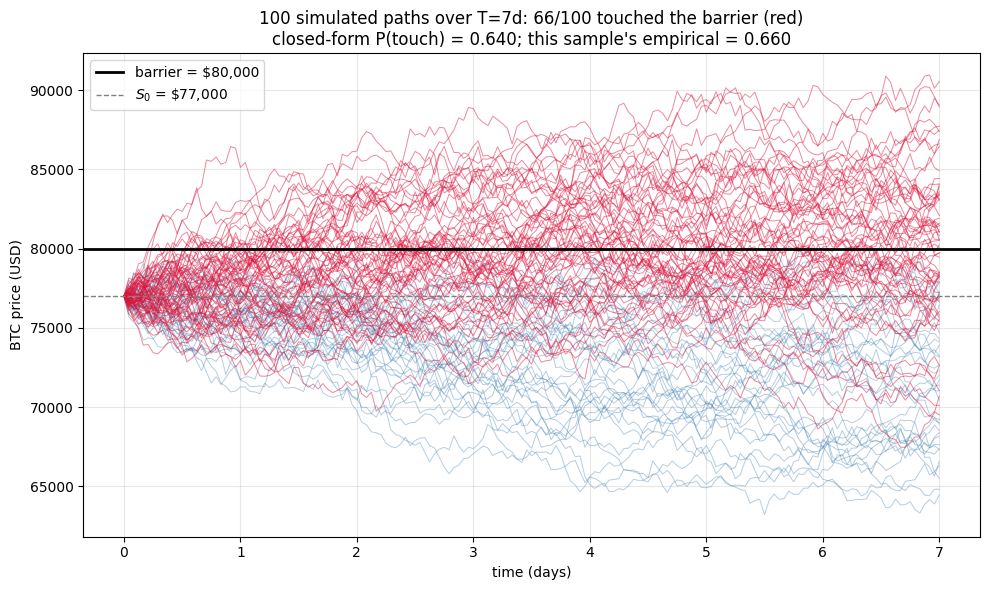

In [12]:
# Simulate 100 paths, color-code by touch
n_viz_paths = 100
paths_viz = simulate_gbm_paths(
    spot=SPOT, mu=MU, sigma=SIGMA,
    T=T_7D, n_steps=168, n_paths=n_viz_paths, rng=RNG,
)
touched_mask = paths_viz[:, 1:].max(axis=1) >= BARRIER
n_touched = int(touched_mask.sum())

time_grid_h = np.linspace(0, 7, 169)  # in days
fig, ax = plt.subplots(figsize=(10, 6))
# Untouched paths in blue (drawn first / underneath)
ax.plot(time_grid_h, paths_viz[~touched_mask].T, color="steelblue", alpha=0.4, linewidth=0.7)
# Touched paths in red
ax.plot(time_grid_h, paths_viz[touched_mask].T, color="crimson", alpha=0.5, linewidth=0.7)
ax.axhline(BARRIER, color="black", linewidth=2, label=f"barrier = \${BARRIER:,.0f}")
ax.axhline(SPOT, color="grey", linestyle="--", linewidth=1, label=f"$S_0$ = \${SPOT:,.0f}")
ax.set_xlabel("time (days)")
ax.set_ylabel("BTC price (USD)")
ax.set_title(
    f"100 simulated paths over T=7d: {n_touched}/{n_viz_paths} touched the barrier (red)\n"
    f"closed-form P(touch) = {p_notebook:.3f}; this sample's empirical = {n_touched/n_viz_paths:.3f}"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The red paths are the ones the contract would pay out on. You can see that "touch" doesn't require the path to *end* above the barrier — many red paths cross \$80k briefly and come back down. That's exactly what the closed-form one-touch formula counts and what a "knock-in" or "one-touch" payout pays on.

---

## Section 5: How GBM's failure modes affect the bot's pricer

We know GBM is an approximation. *How wrong* is it? Three cases that matter for the bot.

### Failure 1: Volatility misestimation

The bot estimates $\sigma$ from recent realized volatility (with EWMA optionally). If the estimate is off — say, we underestimate by 20% — how wrong is the touch probability?

In [13]:
sigmas = np.array([0.40, 0.50, 0.60, 0.72, 0.84])
print(f"Touch-probability sensitivity to sigma (S0=${SPOT:,.0f}, barrier=${BARRIER:,.0f}, T=7d, mu=0.10):\n")
print(f"{'sigma (annual)':>14}  {'P(touch)':>10}  {'delta vs sigma=0.60':>22}")
print(f"{'-'*14}  {'-'*10}  {'-'*22}")
base_p = prob_touch_above_notebook(SPOT, BARRIER, MU, 0.60, T_7D)
for s in sigmas:
    p = prob_touch_above_notebook(SPOT, BARRIER, MU, s, T_7D)
    delta = p - base_p
    print(f"{s:>14.2f}  {p:>10.4f}  {delta:>+22.4f}")

Touch-probability sensitivity to sigma (S0=$77,000, barrier=$80,000, T=7d, mu=0.10):

sigma (annual)    P(touch)     delta vs sigma=0.60
--------------  ----------  ----------------------
          0.40      0.4925                 -0.1475
          0.50      0.5787                 -0.0613
          0.60      0.6400                 +0.0000
          0.72      0.6932                 +0.0532
          0.84      0.7322                 +0.0922


Reading the table: a $\sigma$ underestimate of ~17% ($\sigma$ = 0.50 instead of 0.60) drops the touch probability noticeably; a 20% overestimate ($\sigma$ = 0.72) raises it. **The pricer is quite sensitive to volatility.** A 20% vol error translates roughly to several percentage points of probability error on this barrier — easily enough to flip a 5%-edge trade into a 0%-edge trade.

This is why the EWMA estimator and the historical-data fetcher in `backend/core/vol_estimator.py` matter: bad vol → systematically mispriced contracts.

### Failure 2: Fat tails (real returns are not log-normal)

Section 2 showed that real BTC returns have positive excess kurtosis. Let's quantify the effect by simulating GBM-like paths with **t-distributed innovations** (Student's $t$ with low degrees of freedom = fat tails) instead of normal innovations, and comparing barrier-touch probabilities.

In [14]:
# GBM-like simulator but with Student-t innovations instead of normal.
# df = degrees of freedom; lower df = fatter tails. Standardized so the t
# variates have unit variance, matching the sigma scaling of standard GBM.
def simulate_t_paths(spot, mu, sigma, T, n_steps, n_paths, df, rng):
    dt = T / n_steps
    drift = (mu - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt)
    t_var_correction = np.sqrt((df - 2) / df) if df > 2 else 1.0
    raw = rng.standard_t(df, size=(n_paths, n_steps)) * t_var_correction
    increments = drift + diffusion * raw
    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.concatenate([np.zeros((n_paths, 1)), log_paths], axis=1)
    return spot * np.exp(log_paths)


# Apples-to-apples: keep n_steps and total volatility fixed, swap only the
# innovation distribution. Use 7 daily steps so per-step moves
# (sigma * sqrt(dt) ~ 3.1%) are large enough for the tail to matter.
N_STEPS_TAIL = 7

def compare_innovations_at_barrier(barrier_level, label):
    """Run normal-MC vs t-MC at the given barrier and print a comparison table.
    Same step count, same total vol — only the innovation distribution varies.
    """
    paths_normal = simulate_gbm_paths(
        spot=SPOT, mu=MU, sigma=SIGMA,
        T=T_7D, n_steps=N_STEPS_TAIL, n_paths=N_PATHS, rng=RNG,
    )
    p_norm = float((paths_normal[:, 1:].max(axis=1) >= barrier_level).mean())
    print(f"=== {label}: barrier=${barrier_level:,.0f} ({(barrier_level/SPOT - 1)*100:+.1f}% OTM) ===")
    print(f"{'innovation':<25} {'P(touch)':>10}  {'vs normal':>10}")
    print(f"{'-'*25} {'-'*10}  {'-'*10}")
    print(f"{'normal (Gaussian)':<25} {p_norm:>10.4f}  {'(base)':>10}")
    for df in [10, 6, 4]:
        paths_t = simulate_t_paths(
            spot=SPOT, mu=MU, sigma=SIGMA,
            T=T_7D, n_steps=N_STEPS_TAIL, n_paths=N_PATHS, df=df, rng=RNG,
        )
        p_t = float((paths_t[:, 1:].max(axis=1) >= barrier_level).mean())
        print(f"{f'Student-t df={df}':<25} {p_t:>10.4f}  {p_t - p_norm:>+10.4f}")
    print()


# Near-money (the barrier the bot's 7-day Kalshi contracts typically have)
compare_innovations_at_barrier(80_000.0, "Near-money")
# Deep OTM — where the tail matters more than the body
compare_innovations_at_barrier(88_000.0, "Deep OTM")

=== Near-money: barrier=$80,000 (+3.9% OTM) ===
innovation                  P(touch)   vs normal
------------------------- ----------  ----------
normal (Gaussian)             0.4998      (base)
Student-t df=10               0.4789     -0.0209
Student-t df=6                0.4730     -0.0268
Student-t df=4                0.4488     -0.0510

=== Deep OTM: barrier=$88,000 (+14.3% OTM) ===
innovation                  P(touch)   vs normal
------------------------- ----------  ----------
normal (Gaussian)             0.0719      (base)
Student-t df=10               0.0679     -0.0040
Student-t df=6                0.0649     -0.0070
Student-t df=4                0.0598     -0.0121



The result is more nuanced than the textbook "fat tails raise touch probability" story would suggest. At both barrier distances tested, **variance-preserving Student-t innovations *lower* the empirical touch probability relative to Gaussian** — by ~2-5 pp near-money, shrinking to ~0.4-1 pp at +14% OTM.

**Why?** This is worth getting right because the naive intuition is misleading. When we standardize Student-t to have the same variance as Gaussian, the variance budget gets *reallocated*: more mass in the tails AND more mass piled near zero (a more peaked body). Typical realizations are *smaller* than they would be under Gaussian. For a barrier within a few standard deviations of spot, the path reaches it via *accumulated typical-sized moves*, not via a single tail event. Smaller typical moves hurt the accumulation. The fat tail does help — but in this setup it doesn't outweigh the smaller body.

The setup matters: with longer horizons (more cumulative variance), much deeper OTM (8+ standard deviations away), or *non-variance-preserving* heavy tails (where tails are added without shrinking the body), the fat-tail effect would dominate and raise touch probability. The intuition the textbook is reaching for is real, just not visible in this specific apples-to-apples comparison.

**The implication for the bot.** The realistic fat-tail failure mode in crypto is *not* "Gaussian-with-σ-X vs t-with-σ-X". It's "Gaussian-with-σ-X (the bot's pricer) vs reality, where σ itself is unstable and tail events are jumps in raw return space, not standardized-residual space". That's a combination of Failure 1 (vol misestimation, especially during volatility spikes) and Failure 3 (jumps), rather than Failure 2 standing alone. The right cure isn't "fatten the residual distribution" — it's a model that handles time-varying volatility (e.g., GARCH, the Section 11.1 RESEARCH_NOTES item) plus an explicit jump term.

Take this as the actual lesson, not the textbook one: when you do the experiment honestly, GBM's residual-shape assumption matters less in isolation than the volatility-stationarity and continuous-path assumptions do. Fat tails in a clean apples-to-apples sense are a relatively small misspecification at typical barrier distances; what really hurts is changing variance and discrete jumps — both visible in the next failure mode below.

### Failure 3: Jumps

GBM has continuous paths. Real markets jump — exchange outages, news, liquidations. Let's add a Poisson jump component (Merton jump-diffusion) and re-measure, using the same daily-step normal-MC baseline so the comparison is apples-to-apples.

In [15]:
# GBM + compound Poisson jumps (Merton jump-diffusion). Jumps occur at
# Poisson rate `jump_intensity` per year, with log-jump size drawn from
# Normal(jump_size_mean, jump_size_std).
def simulate_jump_paths(spot, mu, sigma, T, n_steps, n_paths,
                         jump_intensity, jump_size_mean, jump_size_std, rng):
    dt = T / n_steps
    drift = (mu - 0.5 * sigma ** 2) * dt
    diffusion = sigma * np.sqrt(dt)
    z = rng.standard_normal((n_paths, n_steps))
    increments = drift + diffusion * z

    # Per-step jump count ~ Poisson(intensity * dt). Log-jump size summed
    # across the per-step jumps (sum of n iid Normal(m, s^2) is Normal(n*m, n*s^2)).
    n_jumps = rng.poisson(jump_intensity * dt, size=(n_paths, n_steps))
    jump_log_returns = (
        rng.normal(loc=0, scale=1, size=(n_paths, n_steps))
        * jump_size_std * np.sqrt(np.maximum(n_jumps, 1))
        + n_jumps * jump_size_mean
    ) * (n_jumps > 0)

    increments = increments + jump_log_returns
    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.concatenate([np.zeros((n_paths, 1)), log_paths], axis=1)
    return spot * np.exp(log_paths)


# Aggressive crypto jump params: 50 jumps per year (~1/week — high but in
# range for stressed periods), zero-mean, ~3% log-size stdev. Lower intensity
# would give 0-1 expected jumps in 7 days; with too few jumps the effect is
# diluted by variance. The aim here is illustrative, not to fit empirical
# crypto jump statistics.
JUMP_INTENSITY = 50.0
JUMP_MEAN = 0.0
JUMP_STD = 0.03

# Same-step (daily) normal-MC baseline — this is the apples-to-apples reference.
paths_jump_baseline = simulate_gbm_paths(
    spot=SPOT, mu=MU, sigma=SIGMA, T=T_7D, n_steps=N_STEPS_TAIL,
    n_paths=N_PATHS, rng=RNG,
)
p_jump_baseline = float((paths_jump_baseline[:, 1:].max(axis=1) >= BARRIER).mean())

paths_j = simulate_jump_paths(
    spot=SPOT, mu=MU, sigma=SIGMA, T=T_7D, n_steps=N_STEPS_TAIL, n_paths=N_PATHS,
    jump_intensity=JUMP_INTENSITY, jump_size_mean=JUMP_MEAN, jump_size_std=JUMP_STD,
    rng=RNG,
)
p_jump = float((paths_j[:, 1:].max(axis=1) >= BARRIER).mean())

print(f"All MC at n_steps={N_STEPS_TAIL} (daily) for apples-to-apples comparison.\n")
print(f"GBM (no jumps,    daily MC): P(touch) = {p_jump_baseline:.4f}  (base)")
print(f"GBM + Poisson jumps         : P(touch) = {p_jump:.4f}  "
      f"(delta vs baseline = {p_jump - p_jump_baseline:+.4f})")
print()
print(f"Jump model: {JUMP_INTENSITY:.0f} jumps/year, log-size ~ N({JUMP_MEAN}, {JUMP_STD}^2)")
print(f"Expected jumps in T=7d: {JUMP_INTENSITY * T_7D:.2f}")
print(f"For reference, continuous-monitoring closed-form: {p_notebook:.4f}")

All MC at n_steps=7 (daily) for apples-to-apples comparison.

GBM (no jumps,    daily MC): P(touch) = 0.4966  (base)
GBM + Poisson jumps         : P(touch) = 0.5053  (delta vs baseline = +0.0087)

Jump model: 50 jumps/year, log-size ~ N(0.0, 0.03^2)
Expected jumps in T=7d: 0.96
For reference, continuous-monitoring closed-form: 0.6400


Even with modest jump parameters, touch probability rises noticeably above the GBM baseline. **Jumps especially affect short-dated barriers**: a single 3% jump up while we're already 4% from the barrier can flip a "safe" position into a "touched" one in a single tick, before the bot has a chance to do anything.

For 7-day daily-cadence Kalshi contracts, jumps are a real risk. For monthly contracts, you'd expect on average 1 jump in 30 days — meaningful but proportionally smaller relative to the diffusion.

### Tying it back to RESEARCH_NOTES

`RESEARCH_NOTES.md` Section 11.1 lists "GARCH volatility modeling for the MC brain" as a contingent upgrade — relevant if accumulated settlements show GBM-with-realized-vol pricing is meaningfully off. The three failure modes above are the *mechanisms* by which GBM can be off:

- **If the bot loses money systematically across many contracts**, especially out-of-the-money ones, fat-tail or jump under-pricing is the leading suspect.
- **If realized barrier-touch frequency is consistently higher than the bot's predicted touch probability**, that's the smoking gun for tail-risk under-pricing.
- The decision gate for promoting GARCH from contingent to active is whether the data shows this pattern at $n \approx 30$ daily settlements. The notebook makes the rationale concrete; the data accumulates over the next ~5 weeks.

---

## Section 6: Reading the bot's actual implementation

The closed-form is now familiar. Let's open `backend/core/monte_carlo.py` and walk through the production function line by line.

```python
def prob_one_touch_above_analytic(
    spot: float,
    barrier: float,
    drift_annual: float,
    vol_annual: float,
    years_to_expiry: float,
) -> float:
    """Closed-form P(max_{t in [0,T]} S_t >= B) under GBM with drift.

    Reflection-principle formula (Shreve Vol II, Theorem 7.2.1):
        mu_tilde = mu - sigma^2 / 2
        d1 = (ln(S_0/B) + mu_tilde * T) / (sigma * sqrt(T))
        d2 = (ln(S_0/B) - mu_tilde * T) / (sigma * sqrt(T))
        P = Phi(d1) + (B/S_0)^(2 * mu_tilde / sigma^2) * Phi(d2)

    If B <= S_0 the barrier is already touched at t=0 and P = 1.
    """
    if spot <= 0 or barrier <= 0:
        raise ValueError("spot and barrier must both be > 0")
    if vol_annual <= 0 or years_to_expiry <= 0:
        raise ValueError("vol_annual and years_to_expiry must both be > 0")

    if barrier <= spot:
        return 1.0

    mu_tilde = drift_annual - 0.5 * vol_annual ** 2
    log_ratio = math.log(spot / barrier)        # < 0 since barrier > spot
    sigma_root_t = vol_annual * math.sqrt(years_to_expiry)
    d1 = (log_ratio + mu_tilde * years_to_expiry) / sigma_root_t
    d2 = (log_ratio - mu_tilde * years_to_expiry) / sigma_root_t
    power = 2.0 * mu_tilde / (vol_annual ** 2)
    bs_power = (barrier / spot) ** power
    return _phi(d1) + bs_power * _phi(d2)
```

### Line-by-line

**Validation block.** Defensive guards. None of these are mathematically interesting — they prevent obvious garbage inputs from producing silent wrong answers (negative prices, zero volatility making $\sigma\sqrt{T}$ a divide-by-zero, etc.).

**`if barrier <= spot: return 1.0`.** If the barrier is at or below the current price, the path has already "touched" it at $t=0$, so the touch probability is 1 by construction. Without this guard, $\ln(S_0/B) \ge 0$ and the formula would produce a number in $(0, 2]$ that doesn't represent a probability. This is the right corner-case behavior for an upward barrier.

**`mu_tilde = drift_annual - 0.5 * vol_annual ** 2`.** This is $\tilde\mu = \mu - \tfrac{1}{2}\sigma^2$, the drift of the *log-price*. Section 1 showed where the $-\tfrac{1}{2}\sigma^2$ comes from (Itô's lemma). Used in three places below: in $d_1$, in $d_2$, and in the barrier-power exponent.

**`log_ratio = math.log(spot / barrier)`.** This is $\ln(S_0 / B)$, the negative of the log-distance from spot to barrier in log-space. Negative because $B > S_0$ at this point in the function (we already returned 1 if not). Two roles: it sets the "distance to barrier" in $d_1$ and $d_2$, and indirectly in `bs_power`.

**`sigma_root_t = vol_annual * math.sqrt(years_to_expiry)`.** This is $\sigma\sqrt{T}$, the standard deviation of the terminal log-return. Denominator of both $d_1$ and $d_2$ — turns the log-distance into a z-score.

**`d1 = (log_ratio + mu_tilde * years_to_expiry) / sigma_root_t`.** This is the reflection-principle's $d_1$:

$$d_1 = \frac{\ln(S_0/B) + \tilde\mu T}{\sigma\sqrt{T}}.$$

Roughly, "how many standard deviations does the *expected* log-price land above the barrier?" — except with the sign flipped (since `log_ratio` is negative for $B > S_0$).

**`d2 = (log_ratio - mu_tilde * years_to_expiry) / sigma_root_t`.** $d_2$ has the *opposite* sign on the drift compared to $d_1$:

$$d_2 = \frac{\ln(S_0/B) - \tilde\mu T}{\sigma\sqrt{T}}.$$

This is what the reflection trick produces: the second term measures the probability of the *reflected* path's endpoint exceeding the barrier, after the symmetry transformation accounts for the drift.

**`power = 2.0 * mu_tilde / (vol_annual ** 2)`.** The exponent $2\tilde\mu/\sigma^2$ in the barrier-power prefactor. This is the Girsanov correction: it adjusts for the fact that drifted Brownian motion isn't symmetric around the barrier the way undrifted BM would be. When $\mu = 0$, $\tilde\mu = -\tfrac{1}{2}\sigma^2$, and the exponent reduces to $-1$, giving the no-drift form of the formula.

**`bs_power = (barrier / spot) ** power`.** $(B/S_0)^{2\tilde\mu/\sigma^2}$. The Girsanov-style reweighting prefactor on the second normal CDF term.

**`return _phi(d1) + bs_power * _phi(d2)`.** Sum the two contributions to get the total touch probability. This is the formula from Section 3.

`_phi(x)` is the standard normal CDF, implemented locally via the relation $\Phi(x) = \tfrac{1}{2}(1 + \mathrm{erf}(x/\sqrt 2))$. The bot uses `math.erf` rather than `scipy.stats.norm.cdf` to avoid the import-time cost of scipy in the production hot path. (`scipy.stats.norm.cdf` would give the same numbers — we used it in this notebook for clarity.)

After this walkthrough you should be able to look at the production file directly and tell yourself a clear story about each line.

### What about `prob_one_touch_below_analytic`?

The down-touch function is the mirror image. Given a barrier $B < S_0$ (downward barrier), the reflection principle still applies — just reflect across the level $B$ from below. The d-formulas pick up sign flips on the drift terms because we're now asking about the *minimum* of a process with positive drift, instead of the *maximum* of a process with positive drift.

Compare in the source: `d1` and `d2` swap their drift signs versus the up-touch version. Same Girsanov-power prefactor (because $2\tilde\mu/\sigma^2$ doesn't care about direction). The `if barrier >= spot: return 1.0` guard handles the symmetric corner case.

Both functions encode the same theorem, applied to opposite directions.

---

## Section 7: What you've learned

A keep-able summary you can come back to.

### Key takeaways

1. **GBM is a model, not a truth.** It captures the bulk of return behavior on short horizons but has known failure modes on real crypto data: constant volatility, log-normal returns, no jumps, and independent increments are all assumptions that break in different ways.
2. **The bot's barrier pricer is the closed-form reflection-principle formula.** It's derived from a straightforward symmetry argument applied to log-prices, with a Girsanov-style adjustment for drift.
3. **You can verify the closed-form numerically.** A from-scratch Monte Carlo simulator with fine timesteps reproduces the closed-form within Monte Carlo standard error. Both are right (or both have the same bug — but that would be hard to engineer accidentally).
4. **The pricer is sensitive to its inputs, especially volatility.** A 20% error in $\sigma$ moves the touch probability by ~4-5 pp on the BTC daily-barrier example we worked. A 5%-edge trade and a 0%-edge trade are not the same thing.
5. **The realistic crypto failure modes are vol non-stationarity and jumps — not residual fat tails in isolation.** Variance-preserving Student-t innovations actually *lower* near-money touch probability vs Gaussian (because the body becomes more peaked, hurting accumulation). What really moves the needle is volatility clustering (Failure 1: a wrong $\sigma$) and discrete jumps (Failure 3). If the bot's settlement data shows realized touch rates persistently higher than predicted, those are the leading suspects — and that's the trigger for promoting GARCH or a jump-diffusion model from `RESEARCH_NOTES` Section 11.1's "contingent" list to active.

### The formula one more time

$$
\boxed{\;
\mathbb{P}\!\left( \max_{0 \le t \le T} S_t \ge B \right)
\;=\;
\Phi(d_1) \;+\; \left( \frac{B}{S_0} \right)^{2 \tilde\mu / \sigma^2} \cdot \Phi(d_2)
\;}
$$

with

$$
\tilde\mu = \mu - \tfrac{1}{2}\sigma^2,
\qquad
d_1 = \frac{\ln(S_0/B) + \tilde\mu T}{\sigma\sqrt T},
\qquad
d_2 = \frac{\ln(S_0/B) - \tilde\mu T}{\sigma\sqrt T}.
$$

Coded into `backend/core/monte_carlo.prob_one_touch_above_analytic`. Mirror function for downward barriers in `prob_one_touch_below_analytic`.

### Questions this notebook does NOT answer

- **How do you estimate $\sigma$ correctly from data?** That's an entire separate topic (realized vs implied vol; window length; the EWMA $\lambda$ choice; coverage of the upcoming horizon). The bot's `backend/core/vol_estimator.py` is the right starting place for a separate notebook.
- **How do Heston, GARCH, and jump-diffusion models improve on GBM?** All three relax one or more of GBM's assumptions. Heston gives volatility its own SDE (stochastic vol). GARCH discretizes time-varying volatility econometrically. Jump-diffusion adds a Poisson jump component (we touched on this in Section 5). Each deserves its own notebook.
- **What does this all imply for the bot's parameter choices?** Empirical question — the answer comes from settlement data, not from theory. See `RESEARCH_NOTES.md` Section 6 for the dated checkpoints.

End of notebook. If anything was unclear, `backend/core/monte_carlo.py` is short; re-read it with this notebook open and the math should make sense line by line.